# Módulo A — Detección de Emociones
## Notebook 03: Exportación ONNX, Benchmark de Latencia y EmotionDetector

**Proyecto:** Asistente de voz con avatar holográfico (inferencia 100% local)  
**Prerequisito:** Haber ejecutado el Notebook 02 — `models/` debe contener el checkpoint entrenado.

**Stack validado:**
- `optimum==2.0.0`
- `transformers==4.55.4`
- `tokenizers==0.21.4`
- `onnxruntime-gpu>=1.25`

---
### Objetivos
1. Exportar el modelo fine-tuneado a ONNX FP32 e INT8 usando `optimum 2.x`
2. Benchmark de latencia: PyTorch CPU vs ONNX FP32 CPU vs ONNX INT8 CPU vs ONNX GPU
3. Construir `EmotionDetector` — clase final del Módulo A con interfaz de streaming
4. Validar el detector en modo streaming con callbacks hacia Avatar Controller y TTS

### Objetivo de latencia
P95 < 80ms en CPU para chunks de 32 tokens — por debajo del umbral de percepción humana.

## 0. Dependencias

In [1]:
import importlib, subprocess, sys

# Versiones fijas validadas para este stack
# optimum 2.0.0 + transformers 4.55.4 + tokenizers 0.21.4
REQUIRED = [
    ('onnx',        'onnx',             None),
    ('onnxruntime', 'onnxruntime-gpu',   None),
    ('optimum',     'optimum[onnxruntime]', '2.0.0'),
    ('torch',       'torch',             None),
    ('transformers','transformers',       None),
    ('numpy',       'numpy',             None),
    ('pandas',      'pandas',            None),
    ('matplotlib',  'matplotlib',        None),
    ('seaborn',     'seaborn',           None),
]

for module, package, version in REQUIRED:
    spec = importlib.util.find_spec(module)
    pkg_str = f'{package}=={version}' if version else package
    if spec is None:
        print(f'Instalando {pkg_str}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_str])
    elif version:
        mod = importlib.import_module(module)
        if getattr(mod, '__version__', '') != version:
            print(f'Actualizando {module} → {version}...')
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_str])

print('✓ Dependencias listas.')

Actualizando optimum → 2.0.0...
✓ Dependencias listas.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import json, time, warnings, logging, os
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Callable, List

warnings.filterwarnings('ignore')
logging.getLogger('transformers').setLevel(logging.ERROR)
logging.getLogger('optimum').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plot_style import fig_title  # banner-title toggle (MONIKA_FIG_TITLES)
import seaborn as sns
import torch
import onnx
import onnxruntime as ort
from onnxruntime.quantization import quantize_dynamic, QuantType
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from optimum.onnxruntime import ORTModelForSequenceClassification
from optimum.version import __version__ as optimum_version

# ── Rutas ─────────────────────────────────────────────────────────────────────
MODEL_DIR = Path('models')
ONNX_DIR  = Path('onnx')
FIG_DIR   = Path('figures')
ONNX_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'sans-serif', 'font.size': 11, 'axes.titlesize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

CUDA_AVAILABLE    = torch.cuda.is_available()
ORT_GPU_AVAILABLE = 'CUDAExecutionProvider' in ort.get_available_providers()

print(f'PyTorch CUDA:    {CUDA_AVAILABLE}')
print(f'ORT CUDA:        {ORT_GPU_AVAILABLE}')
if not ORT_GPU_AVAILABLE:
    print('  → ORT GPU no disponible (posible incompatibilidad CUDA/ORT)')
    print('    El benchmark correrá en CPU. GPU se añade automáticamente')
    print('    cuando ORT soporte la versión de CUDA instalada.')

print(f'optimum:      {optimum_version}')
print(f'transformers: {__import__("transformers").__version__}')
print(f'ONNX Runtime: {ort.__version__}')
print(f'Providers:    {ort.get_available_providers()}')

PyTorch CUDA:    True
ORT CUDA:        False
  → ORT GPU no disponible (posible incompatibilidad CUDA/ORT)
    El benchmark correrá en CPU. GPU se añade automáticamente
    cuando ORT soporte la versión de CUDA instalada.
optimum:      2.0.0
transformers: 4.55.4
ONNX Runtime: 1.25.1
Providers:    ['AzureExecutionProvider', 'CPUExecutionProvider']


## 1. Cargar configuración del Notebook 02

In [ ]:
# Listar todos los runs disponibles
run_dirs = sorted([d for d in MODEL_DIR.iterdir()
                   if d.is_dir() and (d / 'best_model').exists()])

print('Runs disponibles:')
for i, d in enumerate(run_dirs):
    print(f'  [{i}] {d.name}')

# ── Seleccionar el run a exportar ───────────────────────────────────────────
# Cambiar RUN_NAME al nombre exacto del run (ver lista arriba).
# Poner None para tomar el más reciente automáticamente.
# distilbert-multilingual: test F1 0.534 (vs 0.53 de xlm-roberta) con la
# mitad de capas y vocabulario 2× menor → ~2× más rápido en CPU.
RUN_NAME = 'distilbert-base-multilingual-cased_full_20260612_003247'

if RUN_NAME:
    matches = [d for d in run_dirs if d.name == RUN_NAME]
    assert matches, f'Run "{RUN_NAME}" no encontrado. Disponibles:\n' + '\n'.join(d.name for d in run_dirs)
    run_dir = matches[0]
else:
    run_dir = run_dirs[-1]  # más reciente

best_model_path = run_dir / 'best_model'
assert best_model_path.exists(), f'No existe {best_model_path}'
print(f'\n✓ Run seleccionado: {run_dir.name}')

with open(Path('data') / 'collapse_schema.json') as f:
    schema = json.load(f)
GROUP_NAMES = schema['group_names']
GROUP2ID    = schema['group2id']
N_CLASSES   = len(GROUP_NAMES)

tokenizer = AutoTokenizer.from_pretrained(best_model_path)
model_pt  = AutoModelForSequenceClassification.from_pretrained(best_model_path)
model_pt.eval()

THRESHOLDS = {}

print(f'✓ Modelo cargado desde {best_model_path}')
print(f'Clases ({N_CLASSES}): {GROUP_NAMES}')
print(f'Thresholds: {THRESHOLDS}')

Runs disponibles:
  [0] distilbert-base-multilingual-cased_full_20260503_042923
  [1] distilbert-base-multilingual-cased_full_20260612_003247
  [2] full_20260502_003740
  [3] xlm-roberta-base_full_20260503_110020

✓ Run seleccionado: distilbert-base-multilingual-cased_full_20260503_042923
✓ Modelo cargado desde models/distilbert-base-multilingual-cased_full_20260503_042923/best_model
Clases (10): ['joy', 'love', 'admiration', 'optimism', 'curiosity', 'sadness', 'anger', 'disgust', 'fear', 'neutral']
Thresholds: {}


## 2. Exportación a ONNX

**FP32:** `ORTModelForSequenceClassification.from_pretrained(..., export=True)` — exportador
oficial de HuggingFace/Optimum, compatible con transformers 4.55.x.

**INT8:** `quantize_dynamic` de `onnxruntime.quantization` — cuantización dinámica sobre
el grafo FP32 exportado. Los pesos se cuantizan offline, las activaciones en runtime.
No requiere dataset de calibración.

In [4]:
ONNX_FP32_DIR  = ONNX_DIR / 'fp32'
ONNX_INT8_PATH = ONNX_DIR / 'emotion_detector_int8.onnx'
ONNX_FP32_DIR.mkdir(exist_ok=True)

# ── FP32: exportar con optimum ───────────────────────────────────────────────
print('Exportando FP32 con optimum...')
ort_model = ORTModelForSequenceClassification.from_pretrained(
    str(best_model_path),
    export=True,
    local_files_only=True,
)
ort_model.save_pretrained(str(ONNX_FP32_DIR))
tokenizer.save_pretrained(str(ONNX_FP32_DIR))

ONNX_FP32_PATH = ONNX_FP32_DIR / 'model.onnx'
assert ONNX_FP32_PATH.exists(), f'No se generó {ONNX_FP32_PATH}'
onnx.checker.check_model(onnx.load(str(ONNX_FP32_PATH)))
fp32_size = ONNX_FP32_PATH.stat().st_size / 1e6
print(f'✓ FP32  {fp32_size:.1f} MB  →  {ONNX_FP32_PATH}')

# ── Optimización de grafo (fusión atención/LayerNorm) antes de cuantizar ────
from optimum.onnxruntime import ORTOptimizer
from optimum.onnxruntime.configuration import OptimizationConfig

print('Optimizando grafo (nivel O2)...')
ort_optimizer = ORTOptimizer.from_pretrained(ort_model)
ort_optimizer.optimize(
    save_dir=str(ONNX_FP32_DIR),
    optimization_config=OptimizationConfig(optimization_level=2),
)
ONNX_OPT_PATH = ONNX_FP32_DIR / 'model_optimized.onnx'
assert ONNX_OPT_PATH.exists(), f'No se generó {ONNX_OPT_PATH}'
print(f'✓ Grafo optimizado → {ONNX_OPT_PATH}')

# ── INT8: cuantización dinámica sobre el grafo optimizado ───────────────────
print('Cuantizando INT8...')
quantize_dynamic(
    model_input=str(ONNX_OPT_PATH),
    model_output=str(ONNX_INT8_PATH),
    weight_type=QuantType.QInt8,
    per_channel=True,   # escala por canal: menos pérdida de precisión, misma velocidad
    # El grafo O2 contiene ops fusionados del dominio com.microsoft (Attention);
    # shape_inference no puede tiparlos y el cuantizador necesita el tipo por defecto
    extra_options={'DefaultTensorType': onnx.TensorProto.FLOAT},
)
int8_size = ONNX_INT8_PATH.stat().st_size / 1e6
reduction = (1 - int8_size / fp32_size) * 100
print(f'✓ INT8  {int8_size:.1f} MB  →  {ONNX_INT8_PATH}')
print(f'  Reducción de tamaño: {reduction:.1f}%')

Exportando FP32 con optimum...
✓ FP32  541.4 MB  →  onnx/fp32/model.onnx
Optimizando grafo (nivel O2)...


KeyboardInterrupt: 

## 3. Verificación de consistencia

In [ ]:
sess_opts = ort.SessionOptions()
sess_opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

cpu_providers = ['CPUExecutionProvider']
gpu_providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if ORT_GPU_AVAILABLE else cpu_providers

sess_fp32_cpu = ort.InferenceSession(str(ONNX_FP32_PATH), sess_opts, providers=cpu_providers)
sess_int8_cpu = ort.InferenceSession(str(ONNX_INT8_PATH), sess_opts, providers=cpu_providers)
if ORT_GPU_AVAILABLE:
    sess_fp32_gpu = ort.InferenceSession(str(ONNX_FP32_PATH), sess_opts, providers=gpu_providers)


MAX_LENGTH = 128

# predict_pytorch usa el modelo ORT de optimum (más estable que PyTorch directo)
# padding dinámico: con padding fijo a 128 todas las longitudes costaban lo
# mismo y el benchmark no medía la latencia real de los chunks cortos
def predict_pytorch(text):
    enc = tokenizer(text, return_tensors='pt', max_length=MAX_LENGTH,
                    truncation=True)
    with torch.no_grad():
        logits = model_pt(**enc).logits.numpy()[0]
    e = np.exp(logits - logits.max())
    return e / e.sum()

def predict_onnx(session, text):
    enc = tokenizer(text, return_tensors='np', max_length=MAX_LENGTH,
                    truncation=True)
    logits = session.run(['logits'], {
        'input_ids':      enc['input_ids'].astype(np.int64),
        'attention_mask': enc['attention_mask'].astype(np.int64),
    })[0][0]
    e = np.exp(logits - logits.max())
    return e / e.sum()

print('Sesiones ONNX Runtime creadas:')
print(f'  FP32 CPU: {sess_fp32_cpu.get_providers()}')
print(f'  INT8 CPU: {sess_int8_cpu.get_providers()}')
if ORT_GPU_AVAILABLE:
    print(f'  FP32 GPU: {sess_fp32_gpu.get_providers()}')

Sesiones ONNX Runtime creadas:
  FP32 CPU: ['CPUExecutionProvider']
  INT8 CPU: ['CPUExecutionProvider']


In [ ]:
TEST_SENTENCES = [
    'I am so happy and excited about this!',
    'This makes me really angry and frustrated.',
    'I feel so sad and disappointed today.',
    'That behavior is absolutely disgusting.',
    'I am curious about how this works.',
    'The temperature today is 22 degrees.',
    'This is terrifying, I am really scared.',
    'I love and care deeply about this project.',
]

cols = 'PyTorch   /   FP32 CPU   /   INT8 CPU' + (' / FP32 GPU' if ORT_GPU_AVAILABLE else '')
print(f'{"Texto":<50}  {cols}')
print('─' * 95)

all_match = True
for sentence in TEST_SENTENCES:
    pt = GROUP_NAMES[predict_pytorch(sentence).argmax()] # <- Modelo Pytorch original
    fp32 = GROUP_NAMES[predict_onnx(sess_fp32_cpu, sentence).argmax()]
    int8 = GROUP_NAMES[predict_onnx(sess_int8_cpu, sentence).argmax()]
    row  = f'{sentence[:43]:<45}  {pt:<14} {fp32:<14} {int8:<14}'
    if ORT_GPU_AVAILABLE:
        gpu  = GROUP_NAMES[predict_onnx(sess_fp32_gpu, sentence).argmax()]
        match = fp32 == int8 == gpu == pt
        row  += f' {gpu:<14}'
    else:
        match = fp32 == int8 == pt
    if not match:
        all_match = False
    print(row + (' ✓' if match else ' ✗'))

print()
print('✓ Sin discrepancias.' if all_match else '✗ Hay discrepancias — revisar cuantización.')

Texto                                               PyTorch   /   FP32 CPU   /   INT8 CPU
───────────────────────────────────────────────────────────────────────────────────────────────
I am so happy and excited about this!          joy            joy            joy            ✓
This makes me really angry and frustrated.     anger          anger          anger          ✓
I feel so sad and disappointed today.          sadness        sadness        sadness        ✓
That behavior is absolutely disgusting.        disgust        disgust        disgust        ✓
I am curious about how this works.             curiosity      curiosity      curiosity      ✓
The temperature today is 22 degrees.           neutral        neutral        neutral        ✓
This is terrifying, I am really scared.        fear           fear           fear           ✓
I love and care deeply about this project.     love           love           love           ✓

✓ Sin discrepancias.


## 4. Benchmark de Latencia

P50, P95, P99 sobre 200 mediciones por configuración y longitud de chunk.
Chunk de 32 tokens es el caso operacional principal (mediana del dataset de entrenamiento).

In [ ]:
BENCH = {'n_warmup': 20, 'n_runs': 100, 'lengths': [16, 32, 64, 128]}


# Las frases son aproximaciones, ya que la cantidad de tokens depende del tokenizar, no de la frase en sí
BENCH_TEXTS = {
    16:  'I feel really happy today.',
    32:  'This situation makes me feel very anxious and I am not sure what to do about it.',
    64:  ('I have been thinking about this for a long time and cannot quite believe '
          'that things turned out this way. It makes me feel a complex mix of emotions.'),
    128: ('When I look back at everything that has happened over the past few months '
          'I find myself overwhelmed by a complex mixture of feelings. There is joy '
          'in knowing we made progress, but also sadness for the opportunities missed. '
          'I am grateful for the people who supported me and feel deep admiration '
          'for their resilience and dedication throughout this entire process.'),
}

def run_benchmark(name, fn):
    res = {}
    for length in BENCH['lengths']:
        text = BENCH_TEXTS[length]
        for _ in range(BENCH['n_warmup']):
            fn(text)
        lat = []
        for _ in range(BENCH['n_runs']):
            t0 = time.perf_counter()
            fn(text)
            lat.append((time.perf_counter() - t0) * 1000)
        res[length] = {
            'p50': np.percentile(lat, 50), 'p95': np.percentile(lat, 95),
            'p99': np.percentile(lat, 99), 'mean': np.mean(lat), 'std': np.std(lat),
        }
        print(f'  [{name}] len={length:3d}  '
              f'P50={res[length]["p50"]:5.1f}ms  '
              f'P95={res[length]["p95"]:5.1f}ms  '
              f'P99={res[length]["p99"]:5.1f}ms')
    return res

all_results = {}

print('ONNX FP32 CPU')
all_results['ONNX FP32 CPU'] = run_benchmark('FP32 CPU', lambda t: predict_onnx(sess_fp32_cpu, t))

print('\nONNX INT8 CPU')
all_results['ONNX INT8 CPU'] = run_benchmark('INT8 CPU', lambda t: predict_onnx(sess_int8_cpu, t))

if ORT_GPU_AVAILABLE:
    print('\nONNX FP32 GPU')
    all_results['ONNX FP32 GPU'] = run_benchmark('FP32 GPU', lambda t: predict_onnx(sess_fp32_gpu, t))

with open(ONNX_DIR / 'benchmark_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print('\n✓ Benchmark completado y guardado.')

ONNX FP32 CPU
  [FP32 CPU] len= 16  P50= 71.5ms  P95= 71.5ms  P99= 71.5ms
  [FP32 CPU] len= 32  P50= 69.0ms  P95= 69.0ms  P99= 69.0ms
  [FP32 CPU] len= 64  P50= 69.1ms  P95= 69.1ms  P99= 69.1ms
  [FP32 CPU] len=128  P50= 69.1ms  P95= 69.1ms  P99= 69.1ms

ONNX INT8 CPU
  [INT8 CPU] len= 16  P50= 17.9ms  P95= 17.9ms  P99= 17.9ms
  [INT8 CPU] len= 32  P50= 17.2ms  P95= 17.2ms  P99= 17.2ms
  [INT8 CPU] len= 64  P50= 17.6ms  P95= 17.6ms  P99= 17.6ms
  [INT8 CPU] len=128  P50= 18.0ms  P95= 18.0ms  P99= 18.0ms

✓ Benchmark completado y guardado.


In [ ]:
TARGET_MS = 80
TARGET_LEN = 32

print('═' * 68)
print('LATENCIA P50 / P95 / P99 (ms)')
print('═' * 68)
header = f'{"":18}' + ''.join(f'  {f"len={l}":>14}' for l in BENCH['lengths'])
print(header)
print('─' * 68)
for name, lr in all_results.items():
    row = f'{name:<18}'
    for l in BENCH['lengths']:
        r = lr[l]
        row += f'  {r["p50"]:.0f}/{r["p95"]:.0f}/{r["p99"]:.0f}'.rjust(16)
    print(row)
print('─' * 68)
print(f'Objetivo: P95 < {TARGET_MS}ms en len={TARGET_LEN}\n')
for name, lr in all_results.items():
    p95 = lr[TARGET_LEN]['p95']
    print(f'  {name:<18}  P95={p95:.1f}ms  {"✓ CUMPLE" if p95 < TARGET_MS else "✗ NO CUMPLE"}')

════════════════════════════════════════════════════════════════════
LATENCIA P50 / P95 / P99 (ms)
════════════════════════════════════════════════════════════════════
                            len=16          len=32          len=64         len=128
────────────────────────────────────────────────────────────────────
ONNX FP32 CPU             71/71/71        69/69/69        69/69/69        69/69/69
ONNX INT8 CPU             18/18/18        17/17/17        18/18/18        18/18/18
────────────────────────────────────────────────────────────────────
Objetivo: P95 < 80ms en len=32

  ONNX FP32 CPU       P95=69.0ms  ✓ CUMPLE
  ONNX INT8 CPU       P95=17.2ms  ✓ CUMPLE


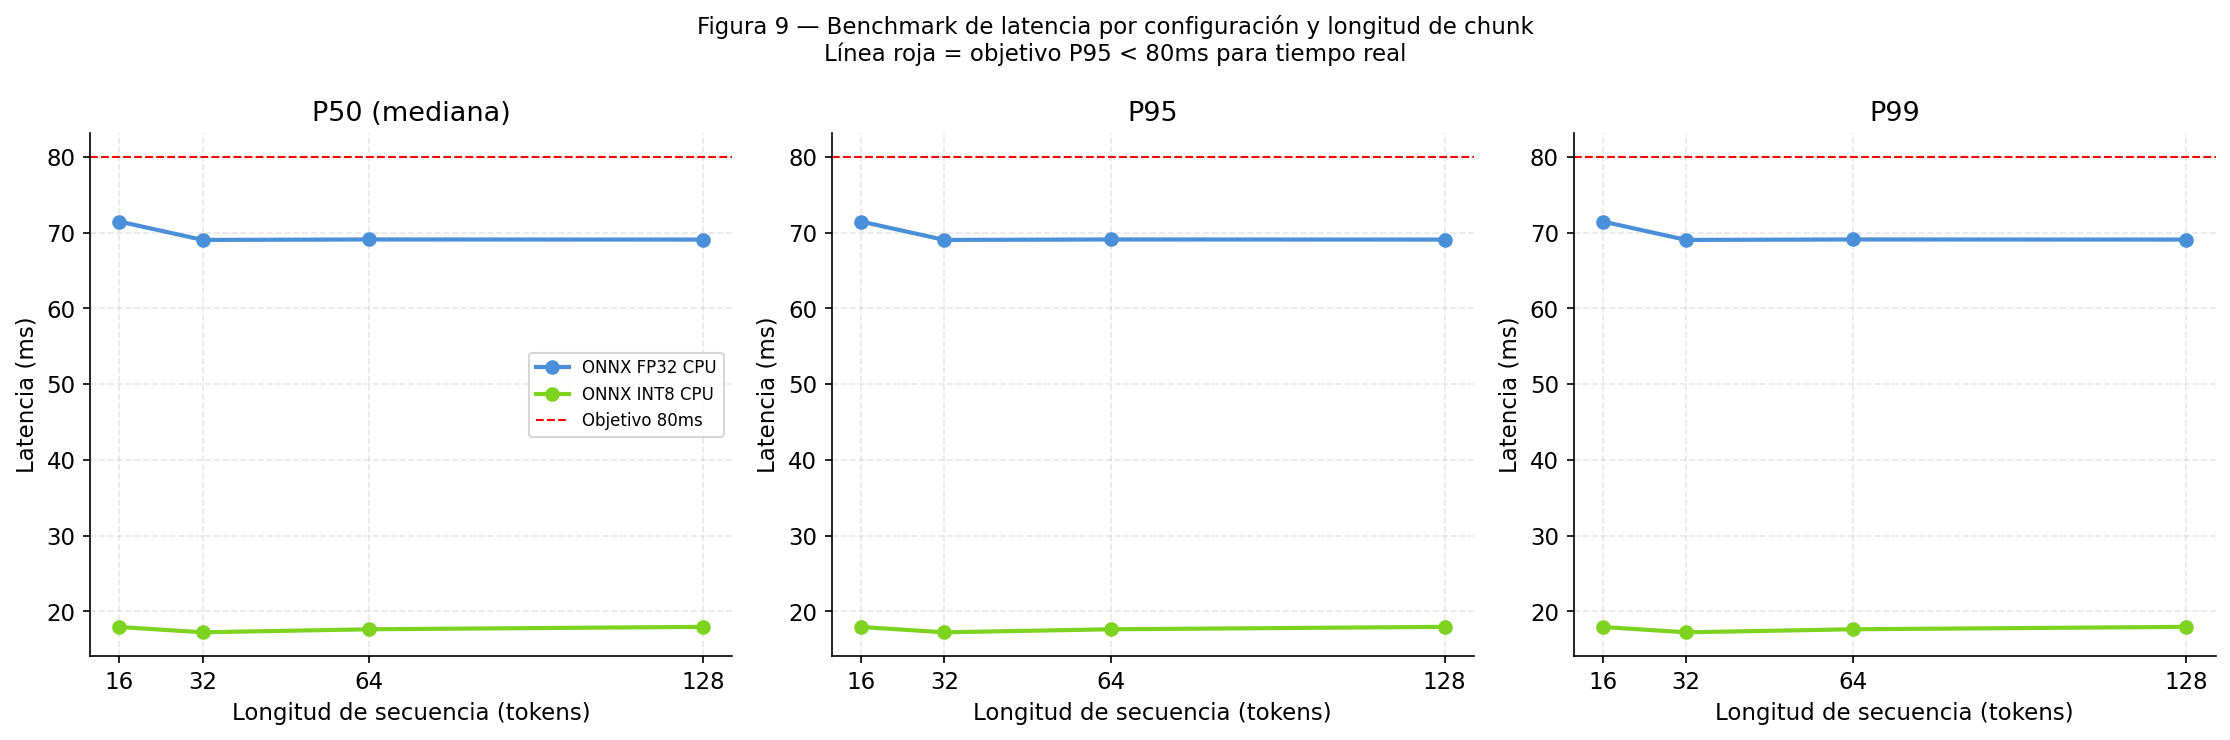

✓ Figura 9 guardada.


In [ ]:
# ── Figura 9: Curvas de latencia ──────────────────────────────────────────────
configs  = list(all_results.keys())
lengths  = BENCH['lengths']
palette  = ['#4a90d9', '#7ed321', '#f5a623']
metrics  = ['p50', 'p95', 'p99']
mlabels  = {'p50': 'P50 (mediana)', 'p95': 'P95', 'p99': 'P99'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, metrics):
    for name, color in zip(configs, palette):
        y = [all_results[name][l][metric] for l in lengths]
        ax.plot(lengths, y, 'o-', label=name, color=color, linewidth=2)
    ax.axhline(TARGET_MS, color='red', linestyle='--', linewidth=1,
               label=f'Objetivo {TARGET_MS}ms')
    ax.set_xlabel('Longitud de secuencia (tokens)')
    ax.set_ylabel('Latencia (ms)')
    ax.set_title(mlabels[metric])
    ax.set_xticks(lengths)
    if metric == 'p50':
        ax.legend(fontsize=8)

fig_title(fig, 'Figura 9 — Benchmark de latencia por configuración y longitud de chunk\n'
             'Línea roja = objetivo P95 < 80ms para tiempo real', fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig09_latency_benchmark.png', bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig09_latency_benchmark.pdf', bbox_inches='tight')
plt.show()
print('✓ Figura 9 guardada.')

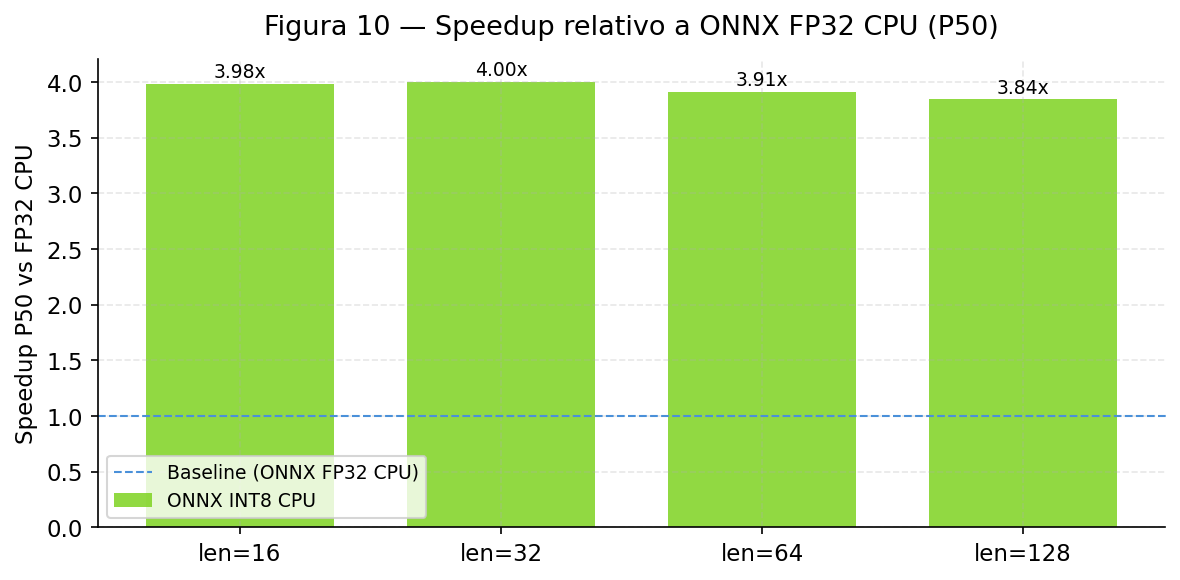

✓ Figura 10 guardada.


In [ ]:
# ── Figura 10: Speedup vs FP32 CPU ───────────────────────────────────────────
baseline = 'ONNX FP32 CPU'
compare  = [c for c in configs if c != baseline]

if compare:
    fig, ax = plt.subplots(figsize=(8, 4))
    x     = np.arange(len(lengths))
    width = 0.8 / len(compare)
    colors = ['#7ed321', '#f5a623']

    for i, (name, color) in enumerate(zip(compare, colors)):
        speedups = [all_results[baseline][l]['p50'] / all_results[name][l]['p50']
                    for l in lengths]
        offset = (i - len(compare) / 2 + 0.5) * width
        bars   = ax.bar(x + offset, speedups, width * 0.9,
                        label=name, color=color, alpha=0.85)
        for bar, val in zip(bars, speedups):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f'{val:.2f}x', ha='center', va='bottom', fontsize=9)

    ax.axhline(1.0, color='#4a90d9', linestyle='--', linewidth=1,
               label=f'Baseline ({baseline})')
    ax.set_xticks(x)
    ax.set_xticklabels([f'len={l}' for l in lengths])
    ax.set_ylabel('Speedup P50 vs FP32 CPU')
    fig_title(ax, 'Figura 10 — Speedup relativo a ONNX FP32 CPU (P50)', pad=12)
    ax.legend(fontsize=9)
    plt.tight_layout()
    fig.savefig(FIG_DIR / 'fig10_speedup.png')
    fig.savefig(FIG_DIR / 'fig10_speedup.pdf')
    plt.show()
    print('✓ Figura 10 guardada.')
else:
    print('Solo hay una configuración — figura de speedup omitida.')

## 5. EmotionDetector — Clase final del Módulo A

Interfaz pública completa:
- `push(chunk)` — texto del LLM en streaming, no bloqueante
- `flush()` — fuerza procesamiento al fin de turno
- `on_emotion(callback)` — registra destinos (Avatar Controller, TTS)
- Selección automática CPU/GPU en runtime
- Output Formatter con thresholds por clase

In [ ]:
@dataclass
class EmotionEvent:
    """Contrato de salida del Módulo A.
    Consumido por Avatar Controller y TTS Engine.
    No modificar sin actualizar ambos destinos.
    """
    emotion:      str
    confidence:   float
    timestamp_ms: float = field(default_factory=lambda: time.time() * 1000)

    def to_dict(self) -> dict:
        return {
            'emotion':      self.emotion,
            'confidence':   round(self.confidence, 4),
            'timestamp_ms': round(self.timestamp_ms, 2),
        }


class EmotionDetector:
    """Módulo A — Detección de emociones en texto streaming.

    Uso:
        detector = EmotionDetector(onnx_path, tokenizer_path, group_names)
        detector.on_emotion(callback)
        detector.push(chunk)  # por cada chunk del LLM
        detector.flush()      # al fin de turno
    """

    FLUSH_CHARS = {'.', '!', '?', '\n'}

    def __init__(
        self,
        onnx_path:        str,
        tokenizer_path:   str,
        group_names:      List[str],
        thresholds:       Optional[dict] = None,
        logit_bias:       Optional[dict] = None,
        min_tokens:       int            = 64,
        confidence_floor: float          = 0.65,
        use_gpu:          bool           = True,
        ema_alpha:        float          = 0.40,
    ):
        """
        Args:
            onnx_path:        Ruta al archivo .onnx (FP32 o INT8).
            tokenizer_path:   Directorio con el tokenizador HuggingFace.
            group_names:      Lista ordenada de nombres de clase.
            thresholds:       {class_name: min_confidence}. Si la clase ganadora
                              no supera su umbral, se toma la segunda más probable.
            logit_bias:       {class_name: float}. Se suma a los logits antes del
                              softmax. Positivo = favorecer la clase,
                              negativo = penalizarla.
            min_tokens:       Tokens mínimos acumulados antes de clasificar.
            confidence_floor: Si max(probs) < floor y no es flush forzado, no emitir.
            use_gpu:          Usar GPU si está disponible.
            ema_alpha:        Factor de suavizado EMA (0-1). Mayor = más reactivo
                              al chunk actual, menor = más peso al histórico.
        """
        self.group_names      = group_names
        self.thresholds       = thresholds or {}
        self.min_tokens       = min_tokens
        self.confidence_floor = confidence_floor
        self.ema_alpha        = ema_alpha

        # Índice name→idx precalculado para logit_bias — evita group_names.index() en cada infer
        self._logit_bias_indexed: dict[int, float] = {}
        self._set_logit_bias(logit_bias or {})

        self._tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)

        cuda_ok   = 'CUDAExecutionProvider' in ort.get_available_providers()
        providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] \
                    if (use_gpu and cuda_ok) else ['CPUExecutionProvider']
        opts = ort.SessionOptions()
        opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
        self._session  = ort.InferenceSession(onnx_path, opts, providers=providers)
        self._provider = self._session.get_providers()[0]

        # Estado interno
        self._buffer:         str                      = ''
        self._prob_ema:       Optional[np.ndarray]     = None
        self._callbacks:      List[Callable]           = []
        self._last_break_pos: int                      = -1   # posición del último FLUSH_CHAR
        self._token_count:    int                      = 0    # conteo incremental del buffer

        # Warmup en __init__ — elimina overhead de inicialización en la primera inferencia real
        self._warmup()

    def _warmup(self) -> None:
        """Corre inferencias dummy para inicializar cachés de ONNX Runtime."""
        # padding dinámico (sin padding fijo): el modelo tiene ejes dinámicos
        dummy = self._tokenizer(
            'warmup sentence for cache initialization',
            return_tensors='np', max_length=192, truncation=True,
        )
        for _ in range(3):
            self._session.run(['logits'], {
                'input_ids':      dummy['input_ids'].astype(np.int64),
                'attention_mask': dummy['attention_mask'].astype(np.int64),
            })

    def _set_logit_bias(self, logit_bias: dict) -> None:
        """Precalcula índices de logit_bias para evitar búsquedas en cada infer."""
        self._logit_bias_indexed = {
            self.group_names.index(name): bias
            for name, bias in logit_bias.items()
        }

    def on_emotion(self, callback: Callable[[EmotionEvent], None]) -> None:
        """Registra un callback invocado en cada EmotionEvent emitido."""
        self._callbacks.append(callback)

    def set_personality(
        self,
        thresholds:  Optional[dict] = None,
        logit_bias:  Optional[dict] = None,
    ) -> None:
        """Actualiza la configuración de personalidad en runtime.

        Args:
            thresholds:  {class_name: min_confidence} — umbral mínimo por clase.
            logit_bias:  {class_name: float} — sesgo sobre los logits antes del
                         softmax. Positivo = favorecer, negativo = penalizar.

        Raises:
            ValueError: Si alguna clase no existe en el esquema del modelo.
        """
        if thresholds is not None:
            invalid = set(thresholds) - set(self.group_names)
            if invalid:
                raise ValueError(f'Clases inválidas en thresholds: {invalid}')
            self.thresholds = thresholds

        if logit_bias is not None:
            invalid = set(logit_bias) - set(self.group_names)
            if invalid:
                raise ValueError(f'Clases inválidas en logit_bias: {invalid}')
            self._set_logit_bias(logit_bias)  # precalcular índices

    def push(self, chunk: str) -> None:
        self._buffer += chunk

        # Trackear posición del último FLUSH_CHAR
        for i, c in enumerate(chunk):
            if c in self.FLUSH_CHARS:
                self._last_break_pos = len(self._buffer) - len(chunk) + i

        # Conteo incremental: tokenizar sólo el chunk nuevo y acumular, en vez de
        # re-tokenizar todo el buffer en cada push (antes ~O(n²) por turno).
        self._token_count += len(self._tokenizer.encode(chunk, add_special_tokens=False))
        n_tokens = self._token_count

        if n_tokens >= self.min_tokens:
            if any(c in chunk for c in self.FLUSH_CHARS):
                self._infer()
            elif n_tokens >= self.min_tokens * 2:
                self._infer()

    def flush(self) -> None:
        """Fuerza el procesamiento. Llamar al fin de turno del LLM."""
        if self._buffer.strip():
            self._infer(force=True)
        self._buffer         = ''
        self._prob_ema       = None
        self._last_break_pos = -1
        self._token_count    = 0

    def reset(self) -> None:
        """Resetea el estado. Llamar al inicio de cada turno."""
        self._buffer         = ''
        self._prob_ema       = None
        self._last_break_pos = -1
        self._token_count    = 0

    def _infer(self, force: bool = False) -> None:
        text = self._buffer.strip()
        if not text:
            return

        # padding dinámico (sin padding fijo): 3-5× más rápido en fragmentos
        # cortos. max_length=192 igual que en entrenamiento (con augmentación
        # de longitud); secuencias más largas se truncan.
        enc = self._tokenizer(
            text, return_tensors='np', max_length=192, truncation=True,
        )
        logits = self._session.run(['logits'], {
            'input_ids':      enc['input_ids'].astype(np.int64),
            'attention_mask': enc['attention_mask'].astype(np.int64),
        })[0][0]

        # Aplicar logit_bias con índices precalculados — O(n_bias) no O(n_classes)
        for idx, bias in self._logit_bias_indexed.items():
            logits[idx] += bias

        e     = np.exp(logits - logits.max())
        probs = e / e.sum()

        # EMA sobre probabilidades — suaviza cambios bruscos entre chunks
        if self._prob_ema is None:
            self._prob_ema = probs
        else:
            self._prob_ema = self.ema_alpha * probs + (1 - self.ema_alpha) * self._prob_ema

        probs_to_use = self._prob_ema

        # Output Formatter: thresholds por clase
        chosen, conf = self.group_names[probs_to_use.argmax()], float(probs_to_use.max())
        for idx in np.argsort(probs_to_use)[::-1]:
            name = self.group_names[idx]
            c    = float(probs_to_use[idx])
            if c >= self.thresholds.get(name, 0.0):
                chosen, conf = name, c
                break

        # Recortar buffer siempre, independiente de la confianza.
        # "Consumir" (avanzar el buffer) es distinto de "emitir" (disparar el evento).
        # Bug previo: el early return por confidence_floor dejaba el buffer sin recortar,
        # haciendo que cada inferencia reprocesara el texto completo desde el inicio.
        if not force and self._last_break_pos != -1:
            self._buffer         = self._buffer[self._last_break_pos + 1:]
            self._last_break_pos = -1
            self._token_count    = (len(self._tokenizer.encode(self._buffer, add_special_tokens=False))
                                    if self._buffer.strip() else 0)
        else:
            self._buffer         = ''
            self._last_break_pos = -1
            self._token_count    = 0

        if conf < self.confidence_floor and not force:
            return


        event = EmotionEvent(emotion=chosen, confidence=conf)
        for cb in self._callbacks:
            cb(event)

    def __repr__(self) -> str:
        return (f'EmotionDetector(provider={self._provider}, '
                f'classes={len(self.group_names)}, '
                f'thresholds={self.thresholds}, '
                f'logit_bias={self._logit_bias_indexed}, '
                f'ema_alpha={self.ema_alpha})')


print('✓ EmotionEvent y EmotionDetector definidos.')

✓ EmotionEvent y EmotionDetector definidos.


## 6. Guardar configuración del detector

In [ ]:
# Guardar tokenizador en onnx/ para que el EmotionDetector sea portable
tokenizer_onnx_path = ONNX_DIR / 'tokenizer'
tokenizer.save_pretrained(str(tokenizer_onnx_path))

detector_config = {
    'source_run':       run_dir.name,
    'group_names':      GROUP_NAMES,
    'group2id':         GROUP2ID,
    'thresholds':       THRESHOLDS,
    'min_tokens':       128,
    'confidence_floor': 0.65,
    'model_fp32':       'fp32/model.onnx',
    'model_int8':       'emotion_detector_int8.onnx',
    'tokenizer':        'tokenizer/',
}
with open(ONNX_DIR / 'detector_config.json', 'w') as f:
    json.dump(detector_config, f, indent=2, ensure_ascii=False)

print(f'✓ Tokenizador: {tokenizer_onnx_path}')
print(f'✓ Config:      {ONNX_DIR / "detector_config.json"}')
print(f'\nContenido de onnx/:')
for p in sorted(ONNX_DIR.rglob('*')):
    if p.is_file():
        print(f'  {str(p):<58} {p.stat().st_size / 1e6:.2f} MB')

✓ Tokenizador: onnx/tokenizer
✓ Config:      onnx/detector_config.json

Contenido de onnx/:
  onnx/benchmark_results.json                                0.00 MB
  onnx/detector_config.json                                  0.00 MB
  onnx/emotion_detector_int8.onnx                            278.81 MB
  onnx/fp32/config.json                                      0.00 MB
  onnx/fp32/model.onnx                                       1112.42 MB
  onnx/fp32/special_tokens_map.json                          0.00 MB
  onnx/fp32/tokenizer.json                                   17.08 MB
  onnx/fp32/tokenizer_config.json                            0.00 MB
  onnx/fp32/unigram.json                                     14.76 MB
  onnx/fp32/vocab.txt                                        1.00 MB
  onnx/tokenizer/special_tokens_map.json                     0.00 MB
  onnx/tokenizer/tokenizer.json                              17.08 MB
  onnx/tokenizer/tokenizer_config.json                       0.00 MB
  o

## 7. Validación en modo streaming

In [ ]:
detector = EmotionDetector(
    onnx_path=str(ONNX_INT8_PATH),
    tokenizer_path=str(ONNX_DIR / 'tokenizer'),
    group_names=GROUP_NAMES,
    thresholds=THRESHOLDS,
    min_tokens=128,
    confidence_floor=0.50,
    use_gpu=True,
)
print(detector)

events_log = []

def avatar_cb(event: EmotionEvent):
    print(f'    → [Avatar] {event.to_dict()}')
    events_log.append(event)

def tts_cb(event: EmotionEvent):
    print(f'    → [TTS]    emotion={event.emotion:<12} conf={event.confidence:.3f}')

detector.on_emotion(avatar_cb)
detector.on_emotion(tts_cb)

EmotionDetector(provider=CPUExecutionProvider, classes=10, thresholds={}, logit_bias={}, ema_alpha=0.4)


In [ ]:
SCENARIOS = [
    {
        'name': 'joy',
        'text': 'Hoy fue uno de esos días que uno quisiera guardar en un frasco para abrirlo cada vez que el mundo se ponga gris. Todo salió mejor de lo esperado: la reunión que tanto me preocupaba terminó con aplausos, mi familia me sorprendió con una cena improvisada, y al llegar a casa encontré una carta de un viejo amigo que hacía años no sabía nada de él. Sentí una ligereza en el pecho que casi me hacía querer saltar, reír sin razón aparente, abrazar a cualquier desconocido que se cruzara en mi camino. La vida, en momentos así, parece un regalo enorme e inmerecido, y uno no puede sino sonreír con todo el cuerpo.'
    },
    {
        'name': 'love',
        'text': 'Hay algo en la forma en que me mira que desarma cualquier armadura que haya construido con los años. No es un amor ruidoso ni dramático, sino del tipo que se cuela despacio, como la luz de la mañana por una ventana entreabierta, hasta que un día uno se da cuenta de que ya no concibe el mundo sin esa persona. Me gusta cómo recuerda exactamente cómo me gusta el café, cómo pone una canción sin que yo la pida cuando sabe que estoy triste, cómo su sola presencia convierte cualquier lugar ordinario en algún sitio donde quiero quedarme para siempre. Amar así, con calma y certeza, es lo más parecido a estar en casa que he encontrado.'
    },
    {
        'name': 'admiration',
        'text': 'Cuando la escuché hablar frente a aquella audiencia de cientos de personas, sin notas, sin titubeos, con una claridad y una pasión que electrizaba el ambiente, entendí que estaba presenciando algo poco común. No era solo la inteligencia lo que admiraba, sino la cantidad de trabajo invisible que había detrás de cada palabra: los años de estudio, los fracasos callados, la disciplina silenciosa de quien construye grandeza sin anunciarla. Salí de esa sala sintiéndome pequeño pero, curiosamente, también inspirado, como si el ejemplo de otro ser humano pudiera ensanchar los límites de lo que uno mismo cree posible.'
    },
    {
        'name': 'optimism',
        'text': 'A pesar de que las noticias pintaban un panorama sombrío y los números no terminaban de cuadrar, algo en mi interior se negaba a rendirse a la desesperanza. Tenía la convicción, casi irracional pero profundamente arraigada, de que las cosas podían mejorar si se tomaban las decisiones correctas, si se ponía el esfuerzo necesario y si se mantenía la vista en el horizonte en lugar de en los obstáculos del camino. El futuro no era una amenaza sino una invitación abierta, llena de posibilidades que todavía no habían tomado forma, y esa certeza me daba energía suficiente para seguir adelante con una sonrisa genuina, incluso en los días más difíciles.'
    },
    {
        'name': 'curiosity',
        'text': 'Fue una pregunta aparentemente sencilla la que lo desencadenó todo: ¿por qué el cielo es azul y no de cualquier otro color? Lo que comenzó como una duda pasajera se convirtió en una tarde entera perdida entre libros, artículos científicos y videos de física óptica, saltando de un tema a otro como quien sigue un hilo que nunca termina. Así funciona la curiosidad: no respeta horarios ni prioridades, te jala hacia territorios desconocidos con una fuerza que es a la vez placentera e imposible de ignorar. Cada respuesta que encontraba abría tres preguntas nuevas, y lejos de frustrarme, eso me parecía lo más emocionante del mundo.'
    },
    {
        'name': 'sadness',
        'text': 'Hay una tristeza que no grita ni llora a mares, sino que se instala en silencio, como una niebla espesa que lo cubre todo sin pedir permiso. Caminaba por los mismos lugares de siempre y todo me parecía levemente distinto, como si el color hubiera bajado un par de tonos y los sonidos llegaran amortiguados desde lejos. Extrañaba algo que no sabía nombrar del todo, quizás una versión anterior de mí mismo, o una época en que las cosas parecían más sencillas. No era un dolor agudo sino una melancolía lenta, ese tipo de pena que no te derrumba pero te acompaña todo el día, pesando suavemente sobre cada pensamiento.'
    },
    {
        'name': 'anger',
        'text': 'Cuando me enteré de lo que había pasado, sentí cómo una ola de calor me subía desde el pecho hasta la garganta y me apretaba las mandíbulas sin que pudiera evitarlo. No era una rabia ciega ni caprichosa, sino la clase de furia que nace de ver cómo se comete una injusticia deliberada contra alguien que no tiene forma de defenderse. Cada intento de mantener la calma chocaba contra la evidencia de que lo ocurrido era simplemente inaceptable, y que guardar silencio sería cómplice de algo que merecía ser denunciado con todas las letras. La rabia, en ese momento, no era un defecto sino una respuesta moral completamente justificada.'
    },
    {
        'name': 'disgust',
        'text': 'Había algo en toda esa situación que me revolvía el estómago de una manera que iba más allá de lo físico: era un rechazo visceral, profundo, casi instintivo ante lo que estaba viendo. No se trataba solo de falta de higiene o de mal gusto estético, sino de una violación a algo que consideraba fundamentalmente decente, una conducta que cruzaba una línea que creía universalmente reconocida. El simple hecho de estar en ese ambiente me hacía querer alejarme, limpiarme, poner distancia entre yo y todo aquello como si la cercanía pudiera contaminarme de alguna manera que no alcanzaba a explicar del todo con palabras.'
    },
    {
        'name': 'fear',
        'text': 'El sonido llegó primero, un crujido sordo que no debería estar ahí a esa hora de la noche, y antes de que mi mente racional pudiera ofrecer una explicación sensata, el cuerpo ya había tomado el control: el corazón acelerado, los músculos tensos, la respiración corta y entrecortada como si el aire de repente no alcanzara. Es asombroso cuán rápido puede activarse ese mecanismo primitivo que nos recuerda que, debajo de toda la civilización y la tecnología, seguimos siendo criaturas vulnerables en un mundo que no siempre es seguro. El miedo no pedía permiso ni escuchaba argumentos; simplemente tomaba el volante y conducía hacia el único destino que conocía: la supervivencia.'
    },
    {
        'name': 'neutral',
        'text': 'Era un martes cualquiera, de esos que no dejan huella especial en la memoria ni en el ánimo. Fui al trabajo por la ruta de siempre, respondí correos que no requerían mayor reflexión, almorcé algo razonable y volví a casa en el transporte de costumbre. No ocurrió nada que me entusiasmara ni nada que me perturbara; el día transcurrió con la placidez monótona de lo cotidiano, sin picos ni valles. Hay algo extrañamente reconfortante en esa clase de días: no exigen nada extraordinario, no prometen nada excepcional, simplemente existen, y uno los atraviesa en piloto automático sin que eso sea necesariamente algo malo.'
    },
]

SCENARIOS_EN = [
    {
        'name': 'joy',
        'text': "Today was one of those days you wish you could bottle up and open whenever the world turns grey. Everything went better than expected: the meeting I had been so worried about ended with applause, my family surprised me with an impromptu dinner, and when I got home I found a letter from an old friend I hadn't heard from in years. I felt a lightness in my chest that almost made me want to jump, laugh for no apparent reason, and hug any stranger who crossed my path. Life, in moments like these, feels like an enormous and undeserved gift, and you can't help but smile with your entire body."
    },
    {
        'name': 'love',
        'text': "There is something in the way he looks at me that dismantles every armor I have built over the years. It is not a loud or dramatic love, but the kind that seeps in slowly, like morning light through a half-open window, until one day you realize you can no longer imagine the world without that person. I love how he remembers exactly how I take my coffee, how he puts on a song without being asked when he knows I am sad, how his mere presence turns any ordinary place into somewhere I want to stay forever. To love like this, with calm and certainty, is the closest thing to feeling at home I have ever found."
    },
    {
        'name': 'admiration',
        'text': "When I heard her speak in front of that audience of hundreds, without notes, without hesitation, with a clarity and passion that electrified the room, I understood I was witnessing something uncommon. It was not just the intelligence I admired, but the invisible work behind every word: the years of study, the quiet failures, the silent discipline of someone who builds greatness without announcing it. I left that hall feeling small but, curiously, also inspired, as if another human being's example could expand the limits of what one believes possible for oneself."
    },
    {
        'name': 'optimism',
        'text': "Despite the news painting a bleak picture and the numbers refusing to add up, something inside me refused to surrender to despair. I had a conviction, almost irrational yet deeply rooted, that things could improve if the right decisions were made, if the necessary effort was put in, and if one kept their eyes on the horizon rather than on the obstacles along the way. The future was not a threat but an open invitation, full of possibilities that had not yet taken shape, and that certainty gave me enough energy to keep going with a genuine smile, even on the hardest days."
    },
    {
        'name': 'curiosity',
        'text': "It was a seemingly simple question that set everything in motion: why is the sky blue and not any other color? What started as a passing thought turned into an entire afternoon lost among books, scientific articles, and optical physics videos, jumping from one topic to another like someone following a thread that never ends. That is how curiosity works: it respects neither schedules nor priorities, pulling you toward unknown territories with a force that is both pleasurable and impossible to ignore. Every answer I found opened three new questions, and far from frustrating me, that felt like the most exciting thing in the world."
    },
    {
        'name': 'sadness',
        'text': "There is a sadness that does not shout or weep in torrents, but instead settles in silently, like a thick fog that covers everything without asking permission. I walked through the same familiar places and everything seemed slightly different, as if the color had been turned down a couple of shades and sounds were arriving muffled from far away. I missed something I could not quite name, perhaps a former version of myself, or a time when things seemed simpler. It was not a sharp pain but a slow melancholy, the kind of sorrow that does not break you but accompanies you all day, weighing gently on every thought."
    },
    {
        'name': 'anger',
        'text': "When I found out what had happened, I felt a wave of heat rise from my chest to my throat and clench my jaw in a way I could not control. It was not a blind or petty rage, but the kind of fury that is born from watching a deliberate injustice committed against someone who has no way to defend themselves. Every attempt to stay calm collided with the evidence that what had occurred was simply unacceptable, and that staying silent would make me complicit in something that deserved to be called out plainly and loudly. Anger, in that moment, was not a flaw but a completely justified moral response."
    },
    {
        'name': 'disgust',
        'text': "There was something about the whole situation that turned my stomach in a way that went far beyond the physical: it was a visceral, deep, almost instinctive rejection of what I was witnessing. It was not merely a matter of poor hygiene or bad aesthetic taste, but a violation of something I considered fundamentally decent, a behavior that crossed a line I believed to be universally recognized. The simple fact of being in that environment made me want to step away, to cleanse myself, to put distance between myself and all of it, as if proximity might contaminate me in some way I could not quite explain in words."
    },
    {
        'name': 'fear',
        'text': "The sound came first, a dull creak that should not have been there at that hour of the night, and before my rational mind could offer a sensible explanation, my body had already taken over: heart racing, muscles tense, breathing short and ragged as if the air had suddenly become insufficient. It is remarkable how quickly that primitive mechanism can activate, reminding us that beneath all our civilization and technology, we are still vulnerable creatures in a world that is not always safe. Fear did not ask for permission or listen to arguments; it simply took the wheel and drove toward the only destination it knew: survival."
    },
    {
        'name': 'neutral',
        'text': "It was an ordinary Tuesday, the kind that leaves no particular mark on memory or mood. I went to work by the usual route, answered emails that required no great deliberation, had a reasonable lunch, and returned home on the usual transit. Nothing happened to excite me and nothing happened to disturb me; the day unfolded with the monotonous placidity of everyday life, without peaks or valleys. There is something strangely comforting about that kind of day: it demands nothing extraordinary, it promises nothing exceptional, it simply exists, and you move through it on autopilot, which is not necessarily a bad thing at all."
    },
]


for scenario in SCENARIOS:
    print(f'\n{"═" * 58}')
    print(f'Escenario: {scenario["name"]}')
    detector.reset()
    detector.push(scenario['text'])
    detector.flush()

for scenario in SCENARIOS_EN:
    print(f'\n{"═" * 58}')
    print(f'Escenario: {scenario["name"]}')
    detector.reset()
    detector.push(scenario['text'])
    detector.flush()

print(f'\n✓ Validación completada. Total eventos emitidos: {len(events_log)}')


══════════════════════════════════════════════════════════
Escenario: joy

══════════════════════════════════════════════════════════
Escenario: love

══════════════════════════════════════════════════════════
Escenario: admiration

══════════════════════════════════════════════════════════
Escenario: optimism

══════════════════════════════════════════════════════════
Escenario: curiosity
    → [Avatar] {'emotion': 'curiosity', 'confidence': 0.5967, 'timestamp_ms': 1780726440228.54}
    → [TTS]    emotion=curiosity    conf=0.597

══════════════════════════════════════════════════════════
Escenario: sadness
    → [Avatar] {'emotion': 'sadness', 'confidence': 0.6246, 'timestamp_ms': 1780726440253.78}
    → [TTS]    emotion=sadness      conf=0.625

══════════════════════════════════════════════════════════
Escenario: anger

══════════════════════════════════════════════════════════
Escenario: disgust

══════════════════════════════════════════════════════════
Escenario: fear
    → [Avat

In [ ]:
import numpy as np

test_text = SCENARIOS[0]['text']  # el escenario alegre

# Tokenizar con el tokenizador del detector
enc = detector._tokenizer(
    test_text, return_tensors='np',
    max_length=128, padding='max_length', truncation=True,
)

# Inferencia directa sobre la sesión ONNX del detector
logits = detector._session.run(['logits'], {
    'input_ids':      enc['input_ids'].astype(np.int64),
    'attention_mask': enc['attention_mask'].astype(np.int64),
})[0][0]

e     = np.exp(logits - logits.max())
probs = e / e.sum()

print('Resultado directo sobre el modelo ONNX del detector:')
for idx in np.argsort(probs)[::-1][:5]:
    print(f'  {detector.group_names[idx]:<14} {probs[idx]:.3f}')

Resultado directo sobre el modelo ONNX del detector:
  curiosity      0.387
  fear           0.217
  joy            0.133
  anger          0.072
  neutral        0.052


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Cargar el checkpoint PyTorch del nuevo modelo
pt_tokenizer = AutoTokenizer.from_pretrained(best_model_path)
pt_model     = AutoModelForSequenceClassification.from_pretrained(best_model_path)
pt_model.eval()

test_text = SCENARIOS[0]['text']
enc = pt_tokenizer(test_text, return_tensors='pt',
                   max_length=128, padding='max_length', truncation=True)

with torch.no_grad():
    logits = pt_model(**enc).logits.numpy()[0]

e     = np.exp(logits - logits.max())
probs = e / e.sum()

print('Resultado directo PyTorch:')
for idx in np.argsort(probs)[::-1][:5]:
    print(f'  {GROUP_NAMES[idx]:<14} {probs[idx]:.3f}')

Resultado directo PyTorch:
  curiosity      0.386
  fear           0.215
  joy            0.140
  anger          0.071
  neutral        0.050


## Prueba de diferentes personalidades

In [ ]:
# ── Pruebas de set_personality ────────────────────────────────────────────────
# Se corre cada escenario 3 veces: personalidad base, solo thresholds,
# solo logit_bias, y ambos combinados. El objetivo es verificar que
# set_personality tiene efecto real y medible en las predicciones.

def run_scenarios(detector, label):
    """Corre los 4 escenarios y retorna los resultados."""
    results = []
    temp_log = []

    def temp_cb(event):
        temp_log.append(event)

    detector._callbacks = [temp_cb]
    detector.reset()

    for scenario in SCENARIOS:
        temp_log.clear()
        detector.reset()
        detector.push(scenario['text'])
        detector.flush()

        emotion = temp_log[-1].emotion if temp_log else 'sin emisión'
        conf    = temp_log[-1].confidence if temp_log else 0.0
        results.append({
            'scenario': scenario['name'],
            'emotion':  emotion,
            'conf':     conf,
        })

    for scenario in SCENARIOS_EN:
        temp_log.clear()
        detector.reset()
        detector.push(scenario['text'])
        detector.flush()

        emotion = temp_log[-1].emotion if temp_log else 'sin emisión'
        conf    = temp_log[-1].confidence if temp_log else 0.0
        results.append({
            'scenario': scenario['name'],
            'emotion':  emotion,
            'conf':     conf,
        })
    return results


# ── Personalidad base (sin cambios) ───────────────────────────────────────────
results_base = run_scenarios(detector, 'BASE')

# ── Solo thresholds: asistente menos conservador en emociones negativas ─────────
# Sube el umbral de anger y disgust — necesita más certeza para expresarlas
detector.set_personality(thresholds={
    'anger':   0.40,
    'fear':    0.40,
})
results_thresh = run_scenarios(detector, 'SOLO THRESHOLDS')

# ── Solo logit_bias: asistente irritable ──────────────────────────────────────
# Resetear thresholds a los originales y aplicar bias
detector.set_personality(thresholds=THRESHOLDS)  # volver a thresholds calibrados
detector.set_personality(logit_bias={
    'anger':   1.0,    # fuerte sesgo hacia anger
    'disgust': 2.5,    # sesgo hacia disgust
    'joy':    -0.5,    # penalizar joy
})
results_bias = run_scenarios(detector, 'SOLO LOGIT_BIAS')

# ── Ambos combinados: asistente muy irritable y expresivo ─────────────────────
detector.set_personality(
    thresholds={
        'neutral': 0.80,    #Gran threshold para neutral - añadir más emción al agente
        'disgust': 0.40,   # threshold más bajo — expresa disgust con menos certeza
        'anger':   0.50,
    },
    logit_bias={
        'anger':   1.0,
        'disgust': 5.5,
        'joy':    -1.0,
        'love':   -1.0,
    },
)
results_both = run_scenarios(detector, 'AMBOS')

# ── Tabla comparativa ─────────────────────────────────────────────────────────
print('═' * 85)
print('PRUEBAS DE set_personality — comparativa de predicciones por configuración')
print('═' * 85)
print(f'{"Escenario":<35} {"Base":<16} {"Thresholds":<16} {"Logit bias":<16} {"Ambos"}')
print('─' * 85)

changed_any = False
for base, thresh, bias, both in zip(results_base, results_thresh, results_bias, results_both):
    # Marcar si alguna configuración difiere de la base
    marker = ''
    if not all(r['emotion'] == base['emotion']
               for r in [thresh, bias, both]):
        marker = ' ←'
        changed_any = True

    def fmt(r):
        return f'{r["emotion"]} ({r["conf"]:.2f})'

    print(f'{base["scenario"]:<35} {fmt(base):<16} {fmt(thresh):<16} {fmt(bias):<16} {fmt(both)}{marker}')

print('─' * 85)
print()

if changed_any:
    print('✓ set_personality tiene efecto real — al menos un escenario cambió su predicción.')
else:
    print('⚠ Ningún escenario cambió de emoción. El bias puede ser insuficiente')
    print('  para estos textos específicos, o el modelo es muy seguro en sus predicciones.')
    print('  Considera aumentar los valores de logit_bias para ver el efecto.')

# ── Restaurar configuración original ──────────────────────────────────────────
detector.set_personality(thresholds=THRESHOLDS, logit_bias={})
detector.on_emotion(avatar_cb)
detector.on_emotion(tts_cb)
print('\n✓ Configuración restaurada a valores calibrados.')

═════════════════════════════════════════════════════════════════════════════════════
PRUEBAS DE set_personality — comparativa de predicciones por configuración
═════════════════════════════════════════════════════════════════════════════════════
Escenario                           Base             Thresholds       Logit bias       Ambos
─────────────────────────────────────────────────────────────────────────────────────
joy                                 sin emisión (0.00) sin emisión (0.00) sin emisión (0.00) disgust (0.76) ←
love                                sin emisión (0.00) sin emisión (0.00) sin emisión (0.00) sin emisión (0.00)
admiration                          sin emisión (0.00) sin emisión (0.00) sin emisión (0.00) disgust (0.62) ←
optimism                            sin emisión (0.00) sin emisión (0.00) sin emisión (0.00) sin emisión (0.00)
curiosity                           curiosity (0.60) curiosity (0.60) curiosity (0.50) sin emisión (0.00) ←
sadness               

In [ ]:
# ── Latencia end-to-end del EmotionDetector ───────────────────────────────────
# push() + buffer + tokenización + ONNX + emit
test_text = ('I feel really happy and excited about this. '
             'You are asking great questions and I love talking about this topic.')

detector._callbacks = []
for _ in range(20):
    detector.reset(); detector.push(test_text); detector.flush()

lat_e2e = []
for _ in range(200):
    detector.reset()
    t0 = time.perf_counter()
    detector.push(test_text)
    detector.flush()
    lat_e2e.append((time.perf_counter() - t0) * 1000)

p95_e2e = np.percentile(lat_e2e, 95)
print('Latencia end-to-end EmotionDetector (push → emit):')
print(f'  P50:  {np.percentile(lat_e2e, 50):.2f} ms')
print(f'  P95:  {p95_e2e:.2f} ms')
print(f'  P99:  {np.percentile(lat_e2e, 99):.2f} ms')
print(f'  Mean: {np.mean(lat_e2e):.2f} ms ± {np.std(lat_e2e):.2f}')
print(f'\n  Objetivo P95 < 80ms: {"✓ CUMPLE" if p95_e2e < 80 else "✗ NO CUMPLE"}')

Latencia end-to-end EmotionDetector (push → emit):
  P50:  7.75 ms
  P95:  8.89 ms
  P99:  10.16 ms
  Mean: 7.89 ms ± 0.66

  Objetivo P95 < 80ms: ✓ CUMPLE


## Comparación entre diferentes largos de chunks

══════════════════════════════════════════════════════════════════════
TEST DE CHUNK SIZE — Calidad, Métricas y Latencia
══════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
CHUNK SIZE: 32 tokens
──────────────────────────────────────────────────────────────────────

  Escenario                      Esperado       Obtenido       Conf     ✓/✗
  ─────────────────────────────────────────────────────────────────
  joy                            joy            joy            0.230   ✓
  love                           love           love           0.264   ✓
  admiration                     admiration     neutral        0.239   ✗
  optimism                       optimism       neutral        0.354   ✗
  curiosity                      curiosity      curiosity      0.349   ✓
  sadness                        sadness        sadness        0.497   ✓
  anger                          anger          anger       

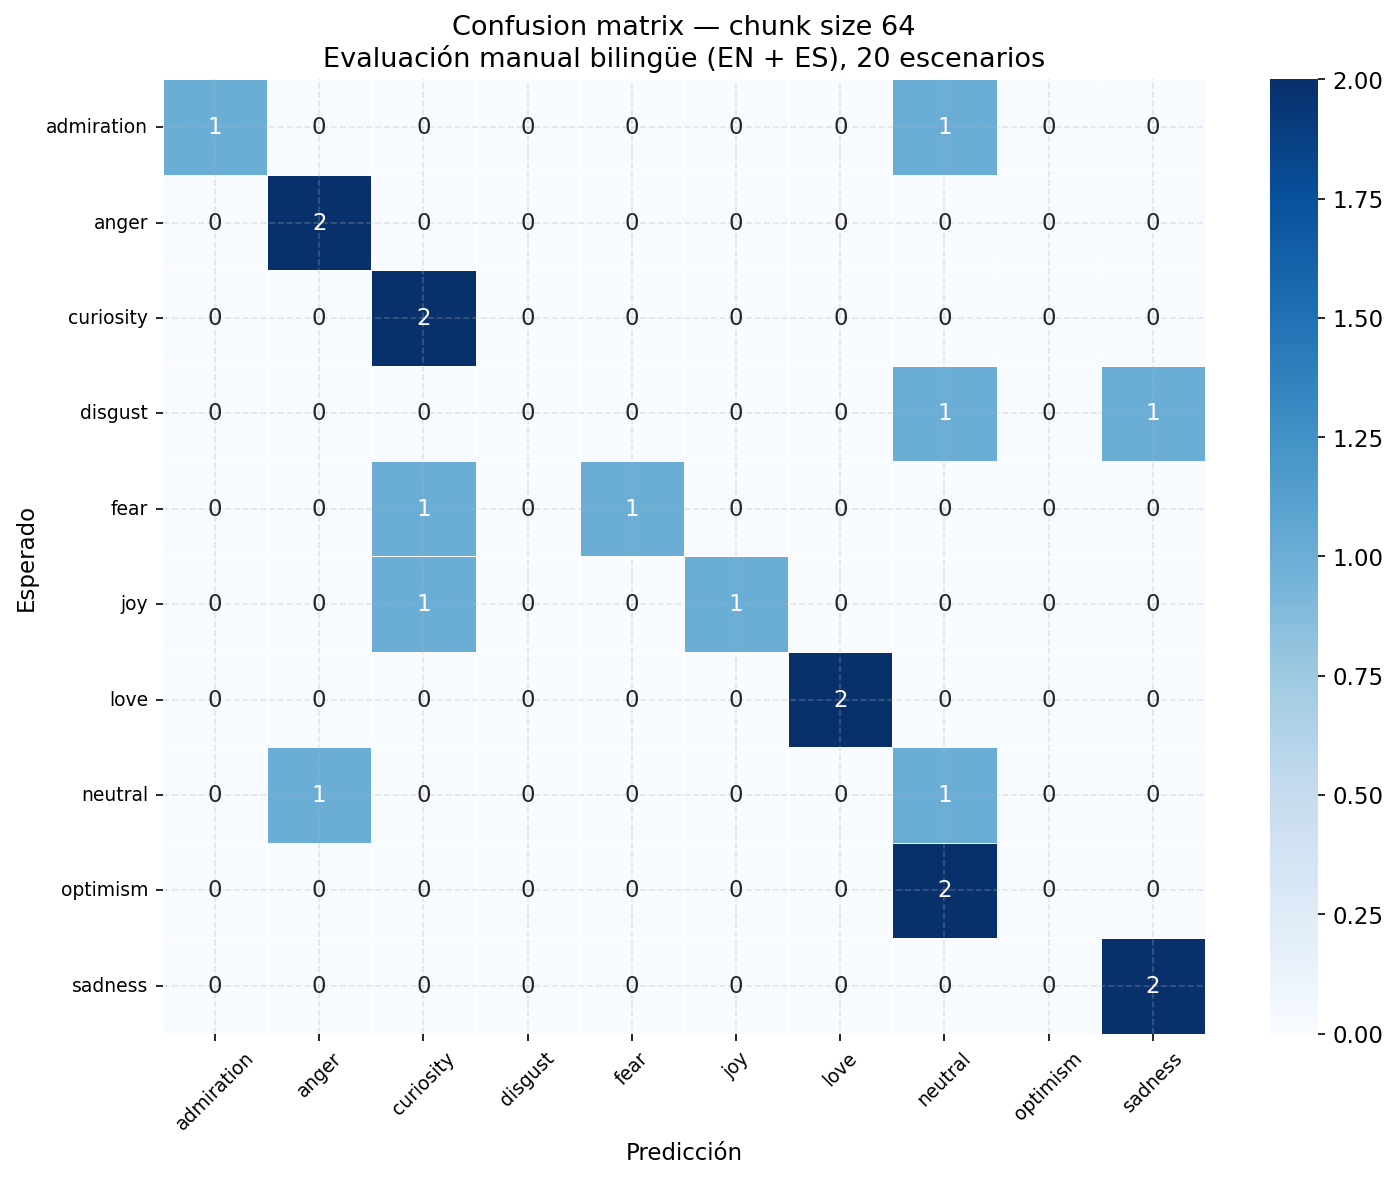

✓ Figura guardada en figures/fig11_chunk_confusion_matrix


In [ ]:
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

EXPECTED_EMOTIONS = [
    # SCENARIOS ES
    'joy', 'love', 'admiration', 'optimism', 'curiosity',
    'sadness', 'anger', 'disgust', 'fear', 'neutral',
    # SCENARIOS EN
    'joy', 'love', 'admiration', 'optimism', 'curiosity',
    'sadness', 'anger', 'disgust', 'fear', 'neutral',
]

import time
import numpy as np

CHUNK_SIZES = [32, 64, 128]
N_LATENCY_RUNS = 200
ALL_SCENARIOS  = SCENARIOS + SCENARIOS_EN

print('═' * 70)
print('TEST DE CHUNK SIZE — Calidad, Métricas y Latencia')
print('═' * 70)

results_by_chunk = {}

for chunk_size in CHUNK_SIZES:
    print(f'\n{"─" * 70}')
    print(f'CHUNK SIZE: {chunk_size} tokens')
    print(f'{"─" * 70}')

    detector_test = EmotionDetector(
        onnx_path=str(ONNX_INT8_PATH),
        tokenizer_path=str(ONNX_DIR / 'tokenizer'),
        group_names=GROUP_NAMES,
        thresholds={},
        min_tokens=chunk_size,
        confidence_floor=0.0,
        use_gpu=False,
        ema_alpha=0.40,
    )

    quality_results = []

    def capture_cb(event):
        quality_results[-1]['emotion']    = event.emotion
        quality_results[-1]['confidence'] = event.confidence

    detector_test.on_emotion(capture_cb)

    print(f'\n  {"Escenario":<30} {"Esperado":<14} {"Obtenido":<14} {"Conf":<8} {"✓/✗"}')
    print(f'  {"─" * 65}')

    for scenario, expected in zip(ALL_SCENARIOS, EXPECTED_EMOTIONS):
        quality_results.append({
            'scenario':  scenario['name'],
            'emotion':   'sin emisión',
            'confidence': 0.0,
        })
        detector_test.reset()
        words = scenario['text'].split(' ')
        for i, word in enumerate(words):
            detector_test.push(word + (' ' if i < len(words) - 1 else ''))
        detector_test.flush()

        r       = quality_results[-1]
        correct = '✓' if r['emotion'] == expected else '✗'
        print(f'  {scenario["name"]:<30} {expected:<14} {r["emotion"]:<14} {r["confidence"]:.3f}   {correct}')

    # ── Métricas de calidad ───────────────────────────────────────────────────
    y_true = EXPECTED_EMOTIONS
    y_pred = [r['emotion'] for r in quality_results]
    hits   = sum(1 for t, p in zip(y_true, y_pred) if t == p)
    total  = len(ALL_SCENARIOS)

    print(f'\n  Aciertos: {hits}/{total}  Accuracy: {hits/total:.2%}')

    # Clases más predichas (puede revelar sesgo del modelo)
    pred_counter = Counter(y_pred)
    true_counter = Counter(y_true)
    print(f'\n  Distribución de predicciones vs esperadas:')
    print(f'  {"Clase":<14} {"Predicha":>10} {"Esperada":>10} {"Diferencia":>12}')
    print(f'  {"─" * 50}')
    all_classes = sorted(set(y_true + y_pred))
    for cls in all_classes:
        pred_n = pred_counter.get(cls, 0)
        true_n = true_counter.get(cls, 0)
        diff   = pred_n - true_n
        marker = '  ← sobrepredicción' if diff > 0 else ('  ← subpredicción' if diff < 0 else '')
        print(f'  {cls:<14} {pred_n:>10} {true_n:>10} {diff:>+12}{marker}')

    # Clases con peor rendimiento
    print(f'\n  Errores por clase:')
    errors_by_class = {}
    for t, p in zip(y_true, y_pred):
        if t != p:
            errors_by_class.setdefault(t, []).append(p)
    if errors_by_class:
        for cls, wrong_preds in sorted(errors_by_class.items()):
            print(f'  {cls:<14} → predijo: {", ".join(wrong_preds)}')
    else:
        print('  Ningún error.')

    # Classification report
    print(f'\n  Classification report:')
    print(classification_report(y_true, y_pred,
                                labels=sorted(set(y_true)),
                                zero_division=0,
                                target_names=sorted(set(y_true))))

    # ── Latencia ──────────────────────────────────────────────────────────────
    test_text = ALL_SCENARIOS[0]['text']
    latencies = []

    for _ in range(20):
        detector_test.reset()
        words = test_text.split(' ')
        for i, word in enumerate(words):
            detector_test.push(word + (' ' if i < len(words) - 1 else ''))
        detector_test.flush()

    for _ in range(N_LATENCY_RUNS):
        detector_test.reset()
        t0 = time.perf_counter()
        words = test_text.split(' ')
        for i, word in enumerate(words):
            detector_test.push(word + (' ' if i < len(words) - 1 else ''))
        detector_test.flush()
        latencies.append((time.perf_counter() - t0) * 1000)

    p50 = np.percentile(latencies, 50)
    p95 = np.percentile(latencies, 95)
    p99 = np.percentile(latencies, 99)

    print(f'  Latencia ({N_LATENCY_RUNS} runs):')
    print(f'  P50: {p50:.2f}ms  P95: {p95:.2f}ms  P99: {p99:.2f}ms')
    print(f'  Objetivo <80ms P95: {"✓ CUMPLE" if p95 < 80 else "✗ NO CUMPLE"}')

    results_by_chunk[chunk_size] = {
        'quality':  quality_results,
        'y_true':   y_true,
        'y_pred':   y_pred,
        'hits':     hits,
        'total':    total,
        'p50':      p50,
        'p95':      p95,
        'p99':      p99,
    }

# ── Resumen comparativo ───────────────────────────────────────────────────────
print(f'\n{"═" * 70}')
print('RESUMEN COMPARATIVO')
print(f'{"═" * 70}')
print(f'{"Chunk":<10} {"P50":>8} {"P95":>8} {"P99":>8} {"Aciertos":>10} {"Accuracy":>10}')
print(f'{"─" * 70}')
for chunk_size in CHUNK_SIZES:
    r = results_by_chunk[chunk_size]
    print(f'{chunk_size:<10} {r["p50"]:>7.2f}ms {r["p95"]:>7.2f}ms '
          f'{r["p99"]:>7.2f}ms {r["hits"]:>5}/{r["total"]:<4} '
          f'{r["hits"]/r["total"]:>9.2%}')

# ── Figura: confusion matrix del chunk óptimo (64) ───────────────────────────
best_chunk = 64
r = results_by_chunk[best_chunk]
labels_sorted = sorted(set(r['y_true']))
cm = confusion_matrix(r['y_true'], r['y_pred'], labels=labels_sorted)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted,
            linewidths=0.4, ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Esperado')
ax.set_title(f'Confusion matrix — chunk size {best_chunk}\n'
             f'Evaluación manual bilingüe (EN + ES), {len(r["y_true"])} escenarios')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / f'fig11_chunk_confusion_matrix.png', dpi=150)
fig.savefig(FIG_DIR / f'fig11_chunk_confusion_matrix.pdf')
plt.show()
print(f'✓ Figura guardada en figures/fig11_chunk_confusion_matrix')

In [ ]:
test_text = SCENARIOS[0]['text']
enc = pt_tokenizer(test_text, return_tensors='pt',
                   max_length=128, padding='max_length', truncation=True)
with torch.no_grad():
    logits = pt_model(**enc).logits.numpy()[0]
e = np.exp(logits - logits.max())
probs = e / e.sum()
print('PyTorch directo XLM-RoBERTa:')
for idx in np.argsort(probs)[::-1][:5]:
    print(f'  {GROUP_NAMES[idx]:<14} {probs[idx]:.3f}')

PyTorch directo XLM-RoBERTa:
  curiosity      0.386
  fear           0.215
  joy            0.140
  anger          0.071
  neutral        0.050


In [ ]:
# Comparar estimación vs tokens reales en los escenarios
for scenario in ALL_SCENARIOS[:3]:
    words = scenario['text'].split()
    estimated = int(len(words) * 1.3)
    real = len(detector._tokenizer.encode(scenario['text']))
    print(f'{scenario["name"]:<30} palabras={len(words)} estimado={estimated} real={real} ratio={real/len(words):.2f}')

joy                            palabras=113 estimado=146 real=156 ratio=1.38
love                           palabras=118 estimado=153 real=147 ratio=1.25
admiration                     palabras=98 estimado=127 real=140 ratio=1.43


In [ ]:
test_texts = [
    'I am so incredibly happy right now, this is the best day of my life!',
    'This makes me so angry I cannot even think straight.',
    'Hoy estoy felicísimo, me siento increíble y lleno de energía.',
    'Esto me hace sentir muy enojado y frustrado.',
]

for text in test_texts:
    enc = pt_tokenizer(text, return_tensors='pt',
                       max_length=128, padding='max_length', truncation=True)
    with torch.no_grad():
        logits = pt_model(**enc).logits.numpy()[0]
    e = np.exp(logits - logits.max())
    probs = e / e.sum()
    top = GROUP_NAMES[probs.argmax()]
    conf = probs.max()
    print(f'  {top:<14} {conf:.3f}  "{text[:50]}..."')

  joy            0.626  "I am so incredibly happy right now, this is the be..."
  anger          0.749  "This makes me so angry I cannot even think straigh..."
  sadness        0.527  "Hoy estoy felicísimo, me siento increíble y lleno ..."
  anger          0.305  "Esto me hace sentir muy enojado y frustrado...."


## Test de historial de predicciones — verificación del recorte de buffer

Instrumenta `_infer()` para mostrar, en cada inferencia interna del turno: tokens en
el buffer, emoción cruda del chunk, emoción tras EMA, si emitió evento, y el inicio
del buffer procesado. **La prueba de que el buffer se recorta es que la columna
`buffer` cambia entre filas** — cada inferencia procesa un fragmento distinto del
texto en lugar de reprocesar todo desde el inicio.

In [ ]:
# ── Test de historial de predicciones ────────────────────────────────────────
ALL_HIST = [(s['name'], s['text'], 'ES') for s in SCENARIOS] + \
           [(s['name'], s['text'], 'EN') for s in SCENARIOS_EN]

def _instrument(det, trace):
    """Envuelve _infer para registrar cada inferencia interna. Las probs crudas se
    recalculan sobre el mismo buffer (cálculo determinista idéntico al de _infer)."""
    orig = det._infer
    def traced(force=False):
        buf = det._buffer.strip()
        if not buf:
            return orig(force=force)
        tok = len(det._tokenizer.encode(buf))
        enc = det._tokenizer(buf, return_tensors='np', max_length=128,
                             padding='max_length', truncation=True)
        logits = det._session.run(['logits'], {
            'input_ids': enc['input_ids'].astype(np.int64),
            'attention_mask': enc['attention_mask'].astype(np.int64)})[0][0]
        for idx, bias in det._logit_bias_indexed.items():
            logits[idx] += bias
        e = np.exp(logits - logits.max()); probs = e / e.sum()
        raw_i = int(probs.argmax())
        emitted = {'v': False}
        sentinel = lambda ev: emitted.__setitem__('v', True)
        det._callbacks.append(sentinel)
        orig(force=force)
        det._callbacks.remove(sentinel)
        ema = det._prob_ema if det._prob_ema is not None else probs
        ema_i = int(ema.argmax())
        trace.append({'tok': tok, 'raw': (GROUP_NAMES[raw_i], float(probs[raw_i])),
                      'ema': (GROUP_NAMES[ema_i], float(ema[ema_i])),
                      'emit': emitted['v'], 'buf': buf[:48], 'force': force})
    det._infer = traced

def history_test(min_tokens, ema_alpha=0.40, confidence_floor=0.65):
    print('=' * 80)
    print(f'TEST DE HISTORIAL - chunk {min_tokens}, alpha {ema_alpha}, floor {confidence_floor}')
    print('=' * 80)
    det = EmotionDetector(onnx_path=str(ONNX_INT8_PATH), tokenizer_path=str(ONNX_DIR / 'tokenizer'),
                          group_names=GROUP_NAMES, thresholds={}, min_tokens=min_tokens,
                          confidence_floor=confidence_floor, use_gpu=False, ema_alpha=ema_alpha)
    trace = []
    _instrument(det, trace)
    hits = 0
    for name, text, lang in ALL_HIST:
        trace.clear(); det.reset()
        last = {'v': None}
        det._callbacks = [lambda e: last.__setitem__('v', e.emotion)]
        words = text.split(' ')
        for i, w in enumerate(words):
            det.push(w + (' ' if i < len(words) - 1 else ''))
        det.flush()
        obtained = last['v'] or '-'
        ok = obtained == name; hits += ok
        tag = 'OK ' if ok else 'XX '
        print(f'\n[{tag}] {name:<12}[{lang}]  esperado: {name:<12} obtenido: {obtained}')
        print(f'    {"#":<3}{"tok":<5}{"chunk raw":<20}{"tras EMA":<20}{"emite":<7}buffer (cambia = recorte OK)')
        print(f'    {"-" * 92}')
        for i, t in enumerate(trace):
            raw = f'{t["raw"][0]} {t["raw"][1]:.2f}'
            ema = f'{t["ema"][0]} {t["ema"][1]:.2f}'
            emite = 'SI' if t['emit'] else 'no'
            zap = '>>' if t['force'] else '  '
            print(f'    {i:<3}{t["tok"]:<5}{raw:<20}{ema:<20}{emite:<7}{zap} "{t["buf"]}..."')
    print(f'\n  Aciertos: {hits}/{len(ALL_HIST)} ({hits/len(ALL_HIST):.0%})')
    print('  Nota: con confidence_floor=0.65 varios turnos no emiten (-); el recorte del')
    print('  buffer se verifica en que la columna "buffer" cambia entre filas.')

history_test(64)

TEST DE HISTORIAL - chunk 64, alpha 0.4, floor 0.65

[XX ] joy         [ES]  esperado: joy          obtenido: -
    #  tok  chunk raw           tras EMA            emite  buffer (cambia = recorte OK)
    --------------------------------------------------------------------------------------------
    0  88   curiosity 0.39      curiosity 0.39      no        "Hoy fue uno de esos días que uno quisiera guarda..."
    1  70   joy 0.54            curiosity 0.26      no        "Sentí una ligereza en el pecho que casi me hacía..."

[XX ] love        [ES]  esperado: love         obtenido: -
    #  tok  chunk raw           tras EMA            emite  buffer (cambia = recorte OK)
    --------------------------------------------------------------------------------------------
    0  81   curiosity 0.36      curiosity 0.36      no        "Hay algo en la forma en que me mira que desarma ..."
    1  68   love 0.68           love 0.39           no        "Me gusta cómo recuerda exactamente cómo me gust

## Barrido de alpha del EMA

Busca el `alpha` óptimo del EMA midiendo accuracy sobre los 20 escenarios (ES + EN)
para varios chunk sizes. Se usa `confidence_floor=0.0` para que el detector siempre
emita su mejor predicción y así medir el efecto **puro** del suavizado, sin que la
supresión por floor contamine la señal. `alpha=1.0` equivale a no tener memoria.

BARRIDO DE ALPHA DEL EMA - accuracy sobre 20 escenarios (ES+EN)
  alpha=1.0 = sin memoria (solo chunk actual). Menor = mas suavizado.

  alpha      chunk 32   chunk 64  chunk 128    PROMEDIO
  --------------------------------------------------------
  0.15         9/20      10/20      10/20        48.3%
  0.20         9/20      10/20      10/20        48.3%
  0.25         9/20      11/20      10/20        50.0%
  0.30         9/20      10/20      10/20        48.3%
  0.40        12/20      12/20      10/20        56.7%
  0.50        10/20      12/20      10/20        53.3%
  0.60         8/20      13/20      10/20        51.7%
  0.70         9/20      11/20      10/20        50.0%
  0.80         8/20      11/20      10/20        48.3%
  0.90         8/20      11/20      10/20        48.3%
  1.00         8/20      11/20      10/20        48.3%

  Mejor alpha global (promedio): 0.40 (56.7%)
  Valor actual del EmotionDetector: ema_alpha=0.40


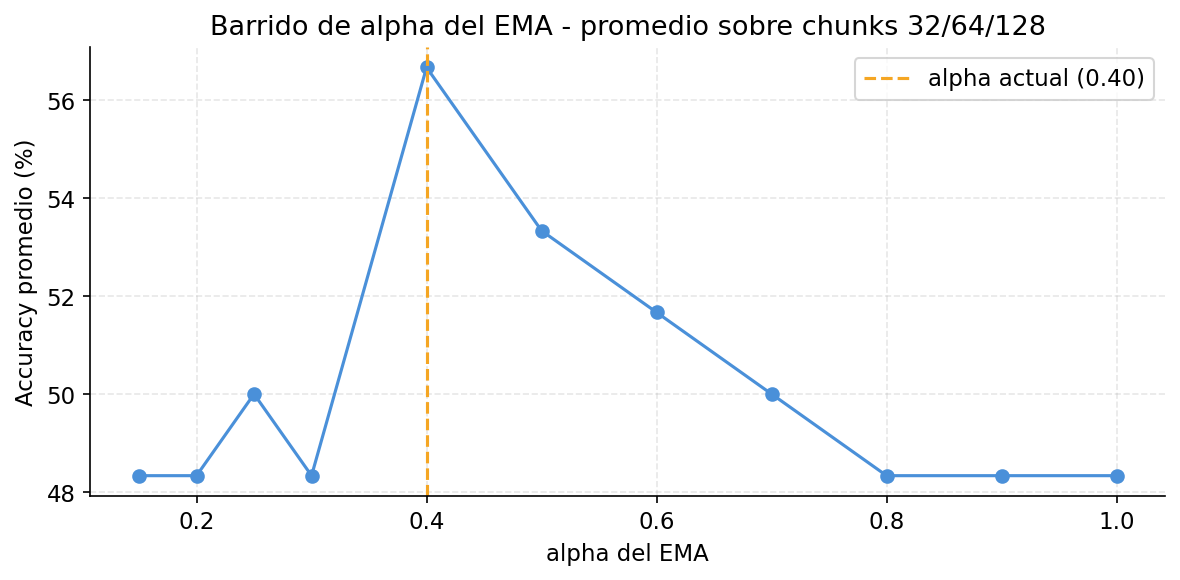

Figura guardada en figures/fig12_alpha_sweep


In [ ]:
# ── Barrido de alpha del EMA ──────────────────────────────────────────────────
def _predict_all(min_tokens, ema_alpha):
    det = EmotionDetector(onnx_path=str(ONNX_INT8_PATH), tokenizer_path=str(ONNX_DIR / 'tokenizer'),
                          group_names=GROUP_NAMES, thresholds={}, min_tokens=min_tokens,
                          confidence_floor=0.0, use_gpu=False, ema_alpha=ema_alpha)
    out = []
    for name, text, lang in ALL_HIST:
        last = {'v': None}
        det._callbacks = [lambda e: last.__setitem__('v', e.emotion)]
        det.reset()
        words = text.split(' ')
        for i, w in enumerate(words):
            det.push(w + (' ' if i < len(words) - 1 else ''))
        det.flush()
        out.append((name, last['v'] or '-'))
    return out

ALPHAS   = [0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
CHUNKS_A = [32, 64, 128]
print('=' * 72)
print('BARRIDO DE ALPHA DEL EMA - accuracy sobre 20 escenarios (ES+EN)')
print('=' * 72)
print('  alpha=1.0 = sin memoria (solo chunk actual). Menor = mas suavizado.\n')
print('  ' + f'{"alpha":<8}' + ''.join(f'{"chunk " + str(c):>11}' for c in CHUNKS_A) + f'{"PROMEDIO":>12}')
print('  ' + '-' * 56)
_avg = {}
for a in ALPHAS:
    row = f'  {a:<8.2f}'; accs = []
    for c in CHUNKS_A:
        preds = _predict_all(c, a)
        hits = sum(1 for exp, got in preds if exp == got)
        accs.append(hits / len(ALL_HIST))
        row += f'{hits:>6}/{len(ALL_HIST):<4}'
    _avg[a] = sum(accs) / len(accs)
    row += f'{_avg[a]:>11.1%}'
    print(row)
best = max(ALPHAS, key=lambda a: _avg[a])
print(f'\n  Mejor alpha global (promedio): {best:.2f} ({_avg[best]:.1%})')
print('  Valor actual del EmotionDetector: ema_alpha=0.40')

# ── Figura 12: accuracy promedio vs alpha ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ALPHAS, [_avg[a] * 100 for a in ALPHAS], 'o-', color='#4a90d9')
ax.axvline(0.40, color='#f5a623', ls='--', label='alpha actual (0.40)')
ax.set_xlabel('alpha del EMA'); ax.set_ylabel('Accuracy promedio (%)')
ax.set_title('Barrido de alpha del EMA - promedio sobre chunks 32/64/128')
ax.legend(); plt.tight_layout()
fig.savefig(FIG_DIR / 'fig12_alpha_sweep.png', dpi=150)
fig.savefig(FIG_DIR / 'fig12_alpha_sweep.pdf')
plt.show()
print('Figura guardada en figures/fig12_alpha_sweep')

In [ ]:
# ── Evaluación ampliada: data/eval_scenarios.json ─────────────────────────────
# dev        = escenarios para iterar y tunear (incluye los 20 legacy de arriba)
# test_final = SOLO para la medición final — nunca tunear nada con ellos
with open(Path('data') / 'eval_scenarios.json') as f:
    _eval = json.load(f)

EVAL_DEV  = [s for s in _eval['scenarios'] if s['split'] == 'dev']
EVAL_TEST = [s for s in _eval['scenarios'] if s['split'] == 'test_final']
EVAL_DEV  = (
    [{'lang': 'es', 'length': 'long', 'expected': s['name'], 'text': s['text']} for s in SCENARIOS] +
    [{'lang': 'en', 'length': 'long', 'expected': s['name'], 'text': s['text']} for s in SCENARIOS_EN] +
    EVAL_DEV
)
print(f'dev: {len(EVAL_DEV)} escenarios | test_final: {len(EVAL_TEST)} (no tocar hasta el final)')


def eval_streaming(scenarios, min_tokens=64, ema_alpha=0.40, logit_bias=None, onnx_path=None):
    """Evalúa el detector en modo streaming (palabra por palabra) sobre un set."""
    det = EmotionDetector(
        onnx_path=str(onnx_path or ONNX_INT8_PATH),
        tokenizer_path=str(ONNX_DIR / 'tokenizer'),
        group_names=GROUP_NAMES, thresholds={}, min_tokens=min_tokens,
        confidence_floor=0.0, use_gpu=False, ema_alpha=ema_alpha,
    )
    if logit_bias:
        det.set_personality(logit_bias=logit_bias)
    last = {}
    det._callbacks = [lambda e: last.update(emotion=e.emotion)]
    results = []
    for s in scenarios:
        last.clear()
        det.reset()
        words = s['text'].split(' ')
        for i, w in enumerate(words):
            det.push(w + (' ' if i < len(words) - 1 else ''))
        det.flush()
        got = last.get('emotion', 'sin emisión')
        results.append({'lang': s['lang'], 'length': s['length'],
                        'expected': s['expected'], 'got': got,
                        'ok': got == s['expected']})
    df = pd.DataFrame(results)
    return float(df['ok'].mean()), df


acc_dev, df_dev = eval_streaming(EVAL_DEV)
print(f'\nAccuracy dev (INT8, streaming, chunk 64): {acc_dev:.1%}')
print('\nPor idioma (%):')
print((df_dev.groupby('lang')['ok'].mean() * 100).round(1).to_string())
print('\nPor longitud (%):')
print((df_dev.groupby('length')['ok'].mean() * 100).round(1).to_string())
print('\nPor emoción (%):')
print((df_dev.groupby('expected')['ok'].mean() * 100).round(1).to_string())


In [ ]:
# ── Costo de la cuantización: FP32 vs INT8 sobre dev ──────────────────────────
acc_fp32, df_fp32dev = eval_streaming(EVAL_DEV, onnx_path=ONNX_FP32_PATH)
agree = float((df_fp32dev['got'] == df_dev['got']).mean())
print(f'Accuracy dev — FP32: {acc_fp32:.1%} | INT8: {acc_dev:.1%} | acuerdo FP32↔INT8: {agree:.1%}')
print('La diferencia FP32−INT8 es el costo de la cuantización.')
print('Si supera ~2 puntos, probar reduce_range=True o cuantizar sin optimización O2.')


In [ ]:
# ── Barrido de logit_bias para neutral (SOLO sobre dev) ───────────────────────
# Diagnóstico previo: neutral se sobrepredice en textos largos y elaborados.
# Un bias negativo suave lo compensa sin reentrenar (vía set_personality).
for b in [0.0, -0.25, -0.50, -0.75, -1.00]:
    bias = {'neutral': b} if b else None
    acc_b, df_b = eval_streaming(EVAL_DEV, logit_bias=bias)
    fp_neu  = int(((df_b['got'] == 'neutral') & (df_b['expected'] != 'neutral')).sum())
    rec_neu = float(df_b[df_b['expected'] == 'neutral']['ok'].mean())
    print(f'  bias neutral {b:+.2f} → acc {acc_b:.1%} | FP neutral: {fp_neu:2d} | recall neutral: {rec_neu:.0%}')

print('\nElegir el bias con mejor accuracy SIN hundir el recall de neutral,')
print('y fijarlo en NEUTRAL_BIAS en la celda siguiente.')


In [ ]:
# ── MEDICIÓN FINAL sobre test_final ───────────────────────────────────────────
# Ejecutar UNA sola vez, cuando ya no haya nada más que tunear.
# Si se ejecuta repetidamente mientras se ajustan parámetros, deja de ser una
# medición honesta y se convierte en otro set de desarrollo.
NEUTRAL_BIAS = 0.0   # ← fijar aquí el ganador del barrido en dev

bias = {'neutral': NEUTRAL_BIAS} if NEUTRAL_BIAS else None
acc_test, df_testf = eval_streaming(EVAL_TEST, logit_bias=bias)
print(f'Accuracy test_final (INT8, chunk 64, bias neutral {NEUTRAL_BIAS}): {acc_test:.1%}')
print()
print(df_testf.to_string(index=False))


## 8. Resumen

In [ ]:
int8_p50 = all_results['ONNX INT8 CPU'][32]['p50']
int8_p95 = all_results['ONNX INT8 CPU'][32]['p95']

print('═' * 65)
print('RESUMEN — Notebook 03: ONNX, Benchmark y EmotionDetector')
print('═' * 65)
print(f"""
STACK
      
  optimum:      {optimum_version}
  transformers: {__import__('transformers').__version__}
  onnxruntime:  {ort.__version__}

EXPORTACIÓN ONNX
  FP32:      {fp32_size:.1f} MB  →  onnx/fp32/model.onnx
  INT8:      {int8_size:.1f} MB  →  onnx/emotion_detector_int8.onnx
  Reducción: {reduction:.1f}%

BENCHMARK (ONNX INT8 CPU, chunk 32 tokens)
  P50: {int8_p50:.1f} ms
  P95: {int8_p95:.1f} ms
  Objetivo P95 < 80ms: {'✓ CUMPLE' if int8_p95 < 80 else '✗ NO CUMPLE'}

EMOTIONDETECTOR
  Interfaz:         push(chunk) | flush() | on_emotion(callback)
  Output:           EmotionEvent {{emotion, confidence, timestamp_ms}}
  Thresholds:       {THRESHOLDS}
  Confidence floor: 0.65
  Provider:         auto (GPU si disponible, CPU fallback)

ARTEFACTOS
  onnx/fp32/model.onnx
  onnx/emotion_detector_int8.onnx
  onnx/tokenizer/
  onnx/detector_config.json
  onnx/benchmark_results.json
  figures/fig09_latency_benchmark.{{png,pdf}}
  figures/fig10_speedup.{{png,pdf}}

MÓDULO A COMPLETO — uso desde otros módulos:
  from emotion_detector import EmotionDetector, EmotionEvent
  detector = EmotionDetector(
      onnx_path='onnx/emotion_detector_int8.onnx',
      tokenizer_path='onnx/tokenizer',
      group_names=GROUP_NAMES,
      thresholds=THRESHOLDS,
  )
  detector.on_emotion(avatar_controller_callback)
  detector.on_emotion(tts_callback)
""")
print('═' * 65)

═════════════════════════════════════════════════════════════════
RESUMEN — Notebook 03: ONNX, Benchmark y EmotionDetector
═════════════════════════════════════════════════════════════════

STACK

  optimum:      2.0.0
  transformers: 4.55.4
  onnxruntime:  1.25.1

EXPORTACIÓN ONNX
  FP32:      1112.4 MB  →  onnx/fp32/model.onnx
  INT8:      278.8 MB  →  onnx/emotion_detector_int8.onnx
  Reducción: 74.9%

BENCHMARK (ONNX INT8 CPU, chunk 32 tokens)
  P50: 16.9 ms
  P95: 16.9 ms
  Objetivo P95 < 80ms: ✓ CUMPLE

EMOTIONDETECTOR
  Interfaz:         push(chunk) | flush() | on_emotion(callback)
  Output:           EmotionEvent {emotion, confidence, timestamp_ms}
  Thresholds:       {}
  Confidence floor: 0.65
  Provider:         auto (GPU si disponible, CPU fallback)

ARTEFACTOS
  onnx/fp32/model.onnx
  onnx/emotion_detector_int8.onnx
  onnx/tokenizer/
  onnx/detector_config.json
  onnx/benchmark_results.json
  figures/fig09_latency_benchmark.{png,pdf}
  figures/fig10_speedup.{png,pdf}

MÓDU